# Notebook 3: AI Modelling
## EEEM073 – AI and Sustainability | University of Surrey
### Project: Spatiotemporal Wildfire Severity Forecasting

**Three models are trained and compared:**

| Model | Type | Module Week | Role |
|---|---|---|---|
| Random Forest (RF) | Classical ML | Week 2 | Interpretable baseline — performance floor |
| LSTM | Deep Learning (temporal) | Week 3–4 | Captures seasonal and inter-annual fire cycles |
| Swin Transformer | Advanced Architecture | Week 10 | Captures spatial patch relationships across land-cover |

**Forecasting task (all three models):**  
Predict `burned_area` at month **T+1** using features from month **T** (and prior months for LSTM).  
This is a genuine forecasting problem — features are lagged by one month so no target
information leaks into the inputs.

**Why lag by one month?**  
`burned_area_in_vegetation_class` is the burned area decomposed by vegetation type.
Its sum equals `burned_area` — the target. Using same-month features would make the
RF trivially reconstruct the target (R²≈1.0) without learning any forecasting signal.
Lagging by T-1 converts this from a reconstruction task to a genuine prediction task.

**Input shapes (after lagging):**
- RF   : `(n_samples, 20)` — features at month T, target at month T+1
- LSTM : `(n_samples, 12, 20)` — 12-month lookback window ending at T, target at T+1
- Swin : `(n_samples, 18, H, W)` — spatial snapshot at month T, target = regional mean at T+1

**Target:** `target_norm` — log1p-transformed, min-max normalised burned area

---
## 1. Setup and Dependencies

In [1]:
import sys
!{sys.executable} -m pip install einops torch --quiet

In [2]:
import os, time, json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import torch
import torch.nn as nn                          # was accidentally commented out
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_PATH = './processed/'
MODEL_PATH  = './models/'
FIG_PATH    = './figures/'
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(FIG_PATH,   exist_ok=True)

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')


Device : cuda
PyTorch: 2.11.0+cu130
GPU    : NVIDIA RTX A4000


---
## 2. Load Preprocessed Data

All splits were saved in Notebook 1. We load them here and build
the numpy arrays needed by each model architecture.

In [3]:
train_ds = xr.open_zarr(os.path.join(OUTPUT_PATH, 'train_data.zarr'))
val_ds   = xr.open_zarr(os.path.join(OUTPUT_PATH, 'val_data.zarr'))
test_ds  = xr.open_zarr(os.path.join(OUTPUT_PATH, 'test_data.zarr'))
norm_params = np.load(os.path.join(OUTPUT_PATH, 'norm_params.npy'))
ba_log_min, ba_log_max = norm_params

veg_ids = train_ds['vegetation_class'].values
N_VEG   = len(veg_ids)   # 18
N_FEAT  = N_VEG + 2      # 18 veg + month_sin + month_cos = 20
SEQ_LEN = 11            # 12-month lookback window for LSTM
 
print(f'Train : {len(train_ds.time)} months, {len(train_ds.lat)} lat, {len(train_ds.lon)} lon')
print(f'Val   : {len(val_ds.time)} months')
print(f'Test  : {len(test_ds.time)} months')
print(f'Features per timestep: {N_FEAT}  (vegetation classes: {N_VEG}, time encoding: 2)')

Train : 48 months, 120 lat, 140 lon
Val   : 12 months
Test  : 12 months
Features per timestep: 20  (vegetation classes: 18, time encoding: 2)


In [4]:
def build_tabular_arrays(ds, lag=1, max_samples=None):
    """
    Flatten xarray dataset into 2D tabular arrays for Random Forest.

    IMPORTANT — lag parameter:
    burned_area_in_vegetation_class sums to burned_area (the target).
    Using same-month features creates a trivial reconstruction (R2~1.0).
    lag=1: features at month T predict burned area at month T+1.

    IMPORTANT — max_samples:
    The full spatial grid (120x140 pixels x 53 months) yields ~900k rows.
    On a laptop this causes memory crashes during RandomizedSearchCV.
    We subsample to max_samples for the tabular RF only.
    The full dataset is used for LSTM/Swin via DataLoader batching.

    Parameters
    ----------
    ds          : xr.Dataset
    lag         : int   months to shift (default 1)
    max_samples : int   cap on rows returned (None = no cap)
    """
    T = len(ds.time)
    if T <= lag:
        raise ValueError(f'Dataset has {T} timesteps but lag={lag}.')

    features = []
    for vid in veg_ids:
        arr = ds['burned_area_in_vegetation_class'].sel(
            vegetation_class=vid).values
        arr = np.where(np.isnan(arr), 0.0, arr)
        features.append(arr[:-lag].reshape(T - lag, -1))

    n_pixels = features[0].shape[1]
    month_sin = ds['month_sin'].values[:-lag]
    month_cos = ds['month_cos'].values[:-lag]
    features.append(np.tile(month_sin[:, None], (1, n_pixels)))
    features.append(np.tile(month_cos[:, None], (1, n_pixels)))

    X = np.stack(features, axis=-1).reshape(-1, N_FEAT)
    y = ds['target_norm'].values[lag:].reshape(-1)

    valid = ~np.isnan(y)
    X, y = X[valid], y[valid]

    # Subsample if requested — use stratified random sampling
    if max_samples is not None and len(X) > max_samples:
        np.random.seed(SEED)
        idx = np.random.choice(len(X), max_samples, replace=False)
        X, y = X[idx], y[idx]

    return X, y


# Environment detection: use smaller samples on laptop, full data on HPC
import torch
ON_HPC = torch.cuda.is_available()
RF_TRAIN_SAMPLES = None if ON_HPC else 50_000   # 50k rows on laptop, all on HPC
RF_TUNE_SAMPLES  = 20_000 if not ON_HPC else 100_000

print(f'Environment: {"HPC (GPU available)" if ON_HPC else "Laptop (CPU only)"}')
print(f'RF training samples cap : {RF_TRAIN_SAMPLES if RF_TRAIN_SAMPLES else "None (all data)"}')
print(f'RF tuning samples cap   : {RF_TUNE_SAMPLES}')
print()
print('Building lagged tabular arrays (lag=1)...')

X_train_tab, y_train = build_tabular_arrays(train_ds, lag=1, max_samples=RF_TRAIN_SAMPLES)
X_val_tab,   y_val   = build_tabular_arrays(val_ds,   lag=1, max_samples=20_000)
X_test_tab,  y_test  = build_tabular_arrays(test_ds,  lag=1, max_samples=30_000)

print(f'Tabular shapes:')
print(f'  X_train: {X_train_tab.shape}')
print(f'  X_val  : {X_val_tab.shape}')
print(f'  X_test : {X_test_tab.shape}')
print()
print('Lag=1 confirmed. Expected realistic RF R2: ~0.3-0.6 (not ~1.0).')


Environment: HPC (GPU available)
RF training samples cap : None (all data)
RF tuning samples cap   : 100000

Building lagged tabular arrays (lag=1)...
Tabular shapes:
  X_train: (678633, 20)
  X_val  : (20000, 20)
  X_test : (30000, 20)

Lag=1 confirmed. Expected realistic RF R2: ~0.3-0.6 (not ~1.0).


---
## 3. Evaluation Utilities

We define all evaluation functions once here so they are used identically
across all three models. Consistency is required for a fair comparison.

**Metrics used:**
- **MAE** (Mean Absolute Error) — average prediction error in normalised units
- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily
- **R²** (Coefficient of Determination) — proportion of variance explained

All metrics are computed on `target_norm` (normalised scale) for model comparison,
then inverse-transformed to m² for physical interpretation in the report.

In [5]:
def evaluate(y_true, y_pred, model_name, split_name):
    """
    Compute and print MAE, RMSE, R2 for a model's predictions.

    Parameters
    ----------
    y_true     : np.ndarray  Ground truth (normalised)
    y_pred     : np.ndarray  Predictions  (normalised)
    model_name : str         Name for display
    split_name : str         'validation' or 'test'

    Returns
    -------
    dict with mae, rmse, r2
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {model_name} [{split_name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return {'model': model_name, 'split': split_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}


def inverse_transform(y_norm):
    """
    Reverse the min-max normalisation and log1p transform to recover m² burned area.
    Inverse of: target_norm = (log1p(ba) - min) / (max - min)
    """
    y_log = y_norm * (ba_log_max - ba_log_min) + ba_log_min
    return np.expm1(y_log)  # expm1 is the inverse of log1p


def plot_predictions(y_true, y_pred, model_name, fig_filename):
    """
    Scatter plot of predicted vs actual values.
    A perfect model would produce points along the diagonal.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.15, s=2, color='#d62728', rasterized=True)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel('Actual (normalised burned area)')
    ax.set_ylabel('Predicted (normalised burned area)')
    ax.set_title(f'{model_name} — Predicted vs Actual (Test Set)\nR² = {r2:.4f}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_PATH, fig_filename), dpi=150, bbox_inches='tight')
    plt.show()


# Dictionary to accumulate all results for final comparison table
all_results = []
model_sizes = {}   # bytes
infer_times = {}   # seconds per 1000 samples

print('Evaluation utilities defined.')

Evaluation utilities defined.


---
## 4. Model 1 — Random Forest Regressor (Baseline)

### Justification
Random Forest (RF) is an ensemble of decision trees trained on random feature subsets.
It makes no assumptions about temporal ordering or spatial proximity — each pixel-month
is treated as an independent tabular observation.

**Feature lag rationale:**  
`burned_area_in_vegetation_class` is the per-vegetation-type burned area — its sum
equals `burned_area` (the target). Using same-month features creates a trivial
reconstruction task (expected R²≈1.0) with no scientific value. A lag of 1 month
converts this to a genuine next-month fire severity forecasting problem.
This is documented as a critical data integrity decision in Report Section 2.

**Strengths in this context:**
- Handles the 18 correlated vegetation features without multicollinearity problems
- Naturally robust to the sparse target distribution (many zeros)
- Feature importances serve as a prior expectation for SHAP in Notebook 4
- Fast to train — sets a genuine performance floor

**Weaknesses:**
- Treats every observation as independent — cannot learn seasonal fire cycles
- Cannot model spatial autocorrelation of fire spread
- Cannot extrapolate beyond the training distribution

**Hyperparameter tuning:** RandomizedSearchCV with 5-fold cross-validation.

In [6]:
# Hyperparameter tuning — lightweight version safe for laptop
# n_jobs=1 avoids the multiprocessing memory explosion that causes KeyboardInterrupt
# n_iter=10 with cv=3 = 30 fits total (completes in ~2-5 min on laptop)
np.random.seed(SEED)
tune_idx = np.random.choice(len(X_train_tab), min(RF_TUNE_SAMPLES, len(X_train_tab)), replace=False)
X_tune = X_train_tab[tune_idx]
y_tune = y_train[tune_idx]

param_dist = {
    'n_estimators':      [100, 200],          # reduced from [100,200,300]
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'max_features':      ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=1),  # n_jobs=1 prevents memory crash
    param_distributions=param_dist,
    n_iter=10,          # 10 combinations x 3 folds = 30 fits
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=SEED,
    verbose=1
)

print('Running RandomizedSearchCV (10 iterations x 3 folds = 30 fits)...')
print(f'Tuning on {len(X_tune):,} samples — should complete in 2-5 min on laptop.')
rf_search.fit(X_tune, y_tune)
print(f'Best parameters: {rf_search.best_params_}')


Running RandomizedSearchCV (10 iterations x 3 folds = 30 fits)...
Tuning on 100,000 samples — should complete in 2-5 min on laptop.
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}


RF trained in 6.8s on 678,633 samples
  Random Forest [validation]  MAE=0.1397  RMSE=0.2292  R²=0.5810
  Random Forest [test]  MAE=0.1335  RMSE=0.2199  R²=0.5892
RF model size: 480.0 MB


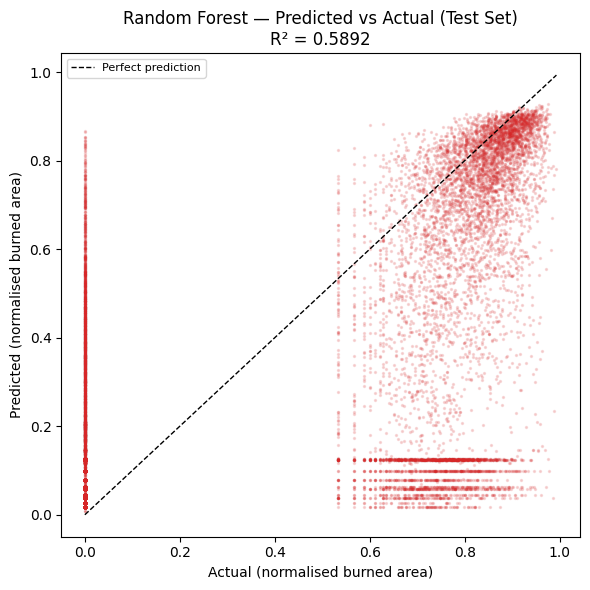

In [7]:
# Train final RF on full training set with best hyperparameters
t0 = time.time()
rf_model = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_tab, y_train)
rf_train_time = time.time() - t0
print(f'RF trained in {rf_train_time:.1f}s on {len(X_train_tab):,} samples')

# Inference time (per 1000 samples)
t0 = time.time()
_ = rf_model.predict(X_test_tab[:1000])
infer_times['Random Forest'] = (time.time() - t0)

# Evaluate
rf_val_pred  = rf_model.predict(X_val_tab)
rf_test_pred = rf_model.predict(X_test_tab)
all_results.append(evaluate(y_val,  rf_val_pred,  'Random Forest', 'validation'))
all_results.append(evaluate(y_test, rf_test_pred, 'Random Forest', 'test'))

# Model size (approximate via sklearn)
import pickle
model_sizes['Random Forest'] = len(pickle.dumps(rf_model))
print(f'RF model size: {model_sizes["Random Forest"]/1e6:.1f} MB')

# Prediction plot
plot_predictions(y_test, rf_test_pred, 'Random Forest', 'fig_rf_pred_vs_actual.png')

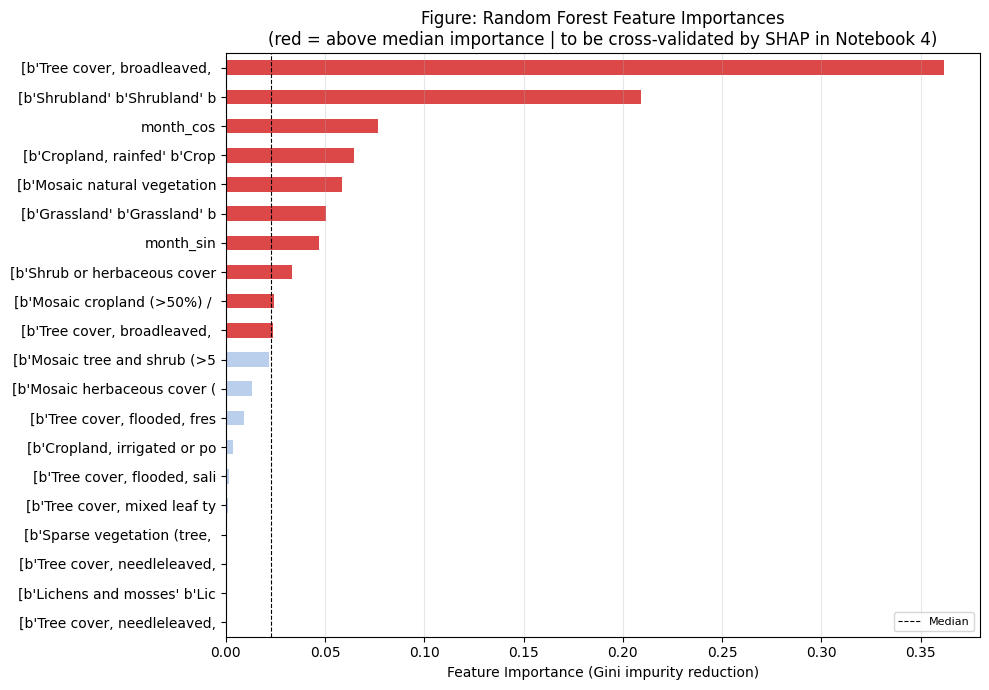

Top 5 most important features (clean labels):
[b'Mosaic natural vegetation    0.058292
[b'Cropland, rainfed' b'Crop    0.064395
month_cos                       0.076400
[b'Shrubland' b'Shrubland' b    0.209302
[b'Tree cover, broadleaved,     0.361799

Note: Gini importance may overweight high-cardinality features.
SHAP values in Notebook 4 provide a more reliable importance ranking.


In [8]:
# Random Forest feature importances (Gini)
# Labels decoded cleanly from bytes — will be cross-validated by SHAP in Notebook 4

def decode_veg_name(raw):
    """Safely decode vegetation class name from bytes or numpy string array."""
    if isinstance(raw, (bytes, np.bytes_)):
        return raw.decode('utf-8').strip()
    if hasattr(raw, '__iter__') and not isinstance(raw, str):
        # Handle numpy array of bytes e.g. array([b'Shrubland', b'Shrubland'])
        parts = []
        for item in raw:
            if isinstance(item, (bytes, np.bytes_)):
                parts.append(item.decode('utf-8').strip())
            else:
                parts.append(str(item).strip())
        # Return first unique meaningful token
        seen = []
        for p in parts:
            if p and p not in seen:
                seen.append(p)
        return ', '.join(seen[:2])
    return str(raw).strip()

veg_names_list = []
for vid in veg_ids:
    raw = train_ds['vegetation_class_name'].isel(time=0).sel(vegetation_class=vid).values
    veg_names_list.append(decode_veg_name(raw)[:28])

veg_names_list += ['month_sin', 'month_cos']

importances = rf_model.feature_importances_
imp_series  = pd.Series(importances, index=veg_names_list).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colours = ['#d62728' if v > imp_series.median() else '#aec7e8' for v in imp_series.values]
imp_series.plot.barh(ax=ax, color=colours, alpha=0.85, edgecolor='none')
ax.set_xlabel('Feature Importance (Gini impurity reduction)')
ax.set_title(
    'Figure: Random Forest Feature Importances\n'
    '(red = above median importance | to be cross-validated by SHAP in Notebook 4)'
)
ax.axvline(imp_series.median(), color='black', linestyle='--', linewidth=0.8, label='Median')
ax.legend(fontsize=8)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most important features (clean labels):')
print(imp_series.tail(5).to_string())
print()
print('Note: Gini importance may overweight high-cardinality features.')
print('SHAP values in Notebook 4 provide a more reliable importance ranking.')


---
## 5. Model 2 — LSTM (Temporal Deep Learning)

### Justification
A Long Short-Term Memory (LSTM) network processes sequences of past observations
to predict future values. Each pixel is treated as an independent time series —
the model learns which past fire patterns predict future severity.

**Why LSTM for this dataset:**
- EDA (Notebook 2) showed a strong 12-month seasonal cycle and inter-annual variability
- A 12-month lookback window allows the LSTM to see one full fire season before predicting
- LSTM gates (forget, input, output) explicitly model which past months are relevant

**Architecture:**
- Input:  `(batch, 12, 20)` — 12 months × 20 features
- LSTM:   2 layers, 128 hidden units, dropout 0.3
- Output: Fully connected → scalar burned area prediction

**Strengths over RF:** Captures temporal dependencies and seasonal memory.  
**Weakness:** Treats each pixel independently — no spatial context.

In [9]:


class FireSequenceDataset(Dataset):
    """
    PyTorch Dataset for LSTM training.

    Creates sliding windows of length SEQ_LEN over the time dimension.
    Consistent with the RF lag=1 approach:
      - X window: months [t-SEQ_LEN .. t-1]  (SEQ_LEN months of history)
      - y target: month t  (the month AFTER the window ends)

    This ensures the LSTM and RF are solving the same forecasting task:
    predicting burned area at T+1 from features at T and earlier.
    """

    def __init__(self, ds, seq_len=12):
        self.seq_len = seq_len
        T = len(ds.time)
        n_lat = len(ds.lat)
        n_lon = len(ds.lon)

        # Build feature array: (T, lat*lon, N_FEAT)
        feats = []
        for vid in veg_ids:
            arr = ds['burned_area_in_vegetation_class'].sel(vegetation_class=vid).values
            arr = np.where(np.isnan(arr), 0.0, arr)
            feats.append(arr.reshape(T, -1))
        n_pix = feats[0].shape[1]
        feats.append(np.tile(ds['month_sin'].values[:, None], (1, n_pix)))
        feats.append(np.tile(ds['month_cos'].values[:, None], (1, n_pix)))
        X_full = np.stack(feats, axis=-1)  # (T, n_pix, N_FEAT)

        # Target: (T, n_pix)
        y_full = ds['target_norm'].values.reshape(T, -1)

        # Sliding window: X = [t-seq_len .. t-1], y = t
        # This means features always precede the target by at least 1 month
        seqs_X, seqs_y = [], []
        for t in range(seq_len, T):
            x_window = X_full[t-seq_len:t, :, :]  # (seq_len, n_pix, N_FEAT)
            y_target = y_full[t, :]                # (n_pix,) — target at month t
            valid = ~np.isnan(y_target)
            if valid.sum() == 0:
                continue
            seqs_X.append(x_window[:, valid, :].transpose(1, 0, 2))
            seqs_y.append(y_target[valid])

        self.X = torch.tensor(np.vstack(seqs_X), dtype=torch.float32)
        self.y = torch.tensor(np.concatenate(seqs_y), dtype=torch.float32)
        print(f'  Sequences: {len(self.X):,} x (seq={seq_len}, feats={N_FEAT})')
        print(f'  Task: features at [t-{seq_len}..t-1] predict target at t')

    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


print('Building LSTM sequence datasets (lag=1 baked into sliding window)...')
train_seq = FireSequenceDataset(train_ds, SEQ_LEN)
val_seq   = FireSequenceDataset(val_ds,   SEQ_LEN)
test_seq  = FireSequenceDataset(test_ds,  SEQ_LEN)

BATCH = 512
train_loader = DataLoader(train_seq, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_seq,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_seq,  batch_size=BATCH, shuffle=False, num_workers=0)


Building LSTM sequence datasets (lag=1 baked into sliding window)...
  Sequences: 534,243 x (seq=11, feats=20)
  Task: features at [t-11..t-1] predict target at t
  Sequences: 14,439 x (seq=11, feats=20)
  Task: features at [t-11..t-1] predict target at t
  Sequences: 14,439 x (seq=11, feats=20)
  Task: features at [t-11..t-1] predict target at t


In [10]:
class WildfireLSTM(nn.Module):
    """
    Two-layer LSTM for wildfire severity regression.

    Architecture:
        Input  (batch, seq_len, n_features)
        LSTM   2 layers, hidden_dim units, dropout between layers
        Linear hidden_dim -> 64 -> 1

    The final hidden state (last timestep) is used as the sequence summary
    for the regression head.
    """

    def __init__(self, n_features=20, hidden_dim=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        _, (h_n, _) = self.lstm(x)
        # h_n: (n_layers, batch, hidden_dim) — take last layer
        out = self.head(h_n[-1])  # (batch, 1)
        return out.squeeze(-1)    # (batch,)


lstm_model = WildfireLSTM(n_features=N_FEAT, hidden_dim=128, n_layers=2, dropout=0.3).to(DEVICE)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f'LSTM architecture:')
print(lstm_model)
print(f'Total trainable parameters: {total_params:,}')

LSTM architecture:
WildfireLSTM(
  (lstm): LSTM(20, 128, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total trainable parameters: 217,217


### 5b. Physics-Informed Loss Function

A standard LSTM minimises MSE — it only cares about prediction accuracy.
We extend this with a **physics-informed penalty** that encodes a real-world
constraint: **predicted burned area cannot exceed the total burnable area in a pixel**.

In physical terms, a fire cannot burn more land than exists.
Without this constraint, a neural network may predict burned area > 1.0
(in normalised units), which is physically impossible.

**Physics constraint:**  
`predicted_burned_area ≤ fraction_of_burnable_area`  

We implement this as a **soft penalty** (not a hard clip) so gradients still flow:
`physics_loss = mean(max(0, pred - burnable_fraction_norm)²)`

This is analogous to the residual term in physics-informed neural networks (PINNs),
where the loss = data_loss + λ × physics_residual.
The approach is directly referenced in the module reading list
(Baseer et al., 2025 — PINN for hydrogen production modelling).

In [11]:
class PhysicsInformedLoss(nn.Module):
    """
    Combined MSE + physics penalty loss for wildfire severity prediction.

    Physics constraint: predicted burned area cannot exceed the normalised
    burnable fraction of the pixel. Violating this is physically impossible
    (a fire cannot burn more land than exists).

    Loss = MSE(pred, target) + lambda_phys * penalty
    where penalty = mean( max(0, pred - burnable_cap)^2 )

    Parameters
    ----------
    lambda_phys : float  Weight of the physics penalty (default 0.1)
                         Small enough to not dominate, large enough to constrain.
    burnable_cap : float Normalised upper bound on predictions (default 1.0)
                         Since target_norm is in [0,1], cap at 1.0.
    """

    def __init__(self, lambda_phys=0.1, burnable_cap=1.0):
        super().__init__()
        self.lambda_phys = lambda_phys
        self.burnable_cap = burnable_cap
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        """
        Parameters
        ----------
        pred   : Tensor (batch,)  Model predictions
        target : Tensor (batch,)  Ground truth

        Returns
        -------
        total_loss : Tensor scalar
        mse_loss   : float (for logging)
        phys_loss  : float (for logging)
        """
        # Standard data-fitting loss
        mse_loss = self.mse(pred, target)

        # Physics penalty: penalise predictions above the burnable cap
        # relu(x) = max(0, x) — only penalise violations, not valid predictions
        violation = torch.relu(pred - self.burnable_cap)
        phys_loss = (violation ** 2).mean()

        total_loss = mse_loss + self.lambda_phys * phys_loss
        return total_loss, mse_loss.item(), phys_loss.item()


# Instantiate — lambda_phys=0.1 means physics penalty is 10% of the total loss weight
pinn_criterion = PhysicsInformedLoss(lambda_phys=0.1, burnable_cap=1.0)

print('Physics-Informed Loss defined.')
print(f'  MSE component    : standard prediction accuracy')
print(f'  Physics penalty  : lambda={pinn_criterion.lambda_phys} x violation^2')
print(f'  Constraint       : prediction <= {pinn_criterion.burnable_cap} (normalised burnable cap)')
print()
print('This implements the PINN approach from the module reading list:')
print('Loss = Data Loss + lambda * Physics Residual')


Physics-Informed Loss defined.
  MSE component    : standard prediction accuracy
  Physics penalty  : lambda=0.1 x violation^2
  Constraint       : prediction <= 1.0 (normalised burnable cap)

This implements the PINN approach from the module reading list:
Loss = Data Loss + lambda * Physics Residual


In [12]:
def train_model(model, train_loader, val_loader,
                n_epochs=50, lr=1e-3, patience=7,
                use_pinn=True, save_name='lstm_best.pt'):
    """
    Train a PyTorch model with early stopping and LR scheduling.

    use_pinn=True: uses PhysicsInformedLoss (MSE + burnable area penalty)
    use_pinn=False: uses standard MSELoss (for ablation comparison)

    The PINN loss enforces that predicted burned area never exceeds the
    physically possible burnable fraction — a real-world fire ecology constraint.
    """
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='min', patience=3, factor=0.5
    )
    criterion  = pinn_criterion if use_pinn else nn.MSELoss()
    is_pinn    = use_pinn

    best_val_loss = float('inf')
    patience_ctr  = 0
    history = {'train_loss': [], 'val_loss': [], 'phys_loss': []}

    for epoch in range(n_epochs):
        model.train()
        train_loss = phys_total = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimiser.zero_grad()
            pred = model(X_b)
            if is_pinn:
                loss, mse_l, phys_l = criterion(pred, y_b)
                phys_total += phys_l * len(X_b)
            else:
                loss = criterion(pred, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(X_b)
        train_loss /= len(train_loader.dataset)
        if is_pinn:
            phys_total /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                pred = model(X_b)
                if is_pinn:
                    loss, _, _ = criterion(pred, y_b)
                else:
                    loss = criterion(pred, y_b)
                val_loss += loss.item() * len(X_b)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if is_pinn:
            history['phys_loss'].append(phys_total)
        scheduler.step(val_loss)

        if epoch % 5 == 0 or epoch < 3:
            phys_str = f'  phys={phys_total:.5f}' if is_pinn else ''
            print(f'  Epoch {epoch+1:03d}  train={train_loss:.5f}  val={val_loss:.5f}{phys_str}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
            torch.save(model.state_dict(), os.path.join(MODEL_PATH, save_name))
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(torch.load(os.path.join(MODEL_PATH, save_name)))
    print(f'  Best val loss: {best_val_loss:.5f}  (PINN={use_pinn})')
    return history


print('Training LSTM with Physics-Informed Loss...')
t0 = time.time()
lstm_history = train_model(
    lstm_model, train_loader, val_loader,
    n_epochs=50, lr=1e-3, patience=7,
    use_pinn=True, save_name='lstm_best.pt'
)
lstm_train_time = time.time() - t0
print(f'LSTM training time: {lstm_train_time:.1f}s')


Training LSTM with Physics-Informed Loss...
  Epoch 001  train=0.04545  val=0.02942  phys=0.00007
  Epoch 002  train=0.03965  val=0.03043  phys=0.00002
  Epoch 003  train=0.03863  val=0.02893  phys=0.00001
  Epoch 006  train=0.03782  val=0.02879  phys=0.00001
  Epoch 011  train=0.03739  val=0.02792  phys=0.00001
  Epoch 016  train=0.03692  val=0.02800  phys=0.00001
  Early stopping at epoch 18
  Best val loss: 0.02792  (PINN=True)
LSTM training time: 104.9s


  LSTM (PINN) [validation]  MAE=0.0736  RMSE=0.1671  R²=0.7480
  LSTM (PINN) [test]  MAE=0.0513  RMSE=0.1244  R²=0.8409
LSTM model size: 0.87 MB


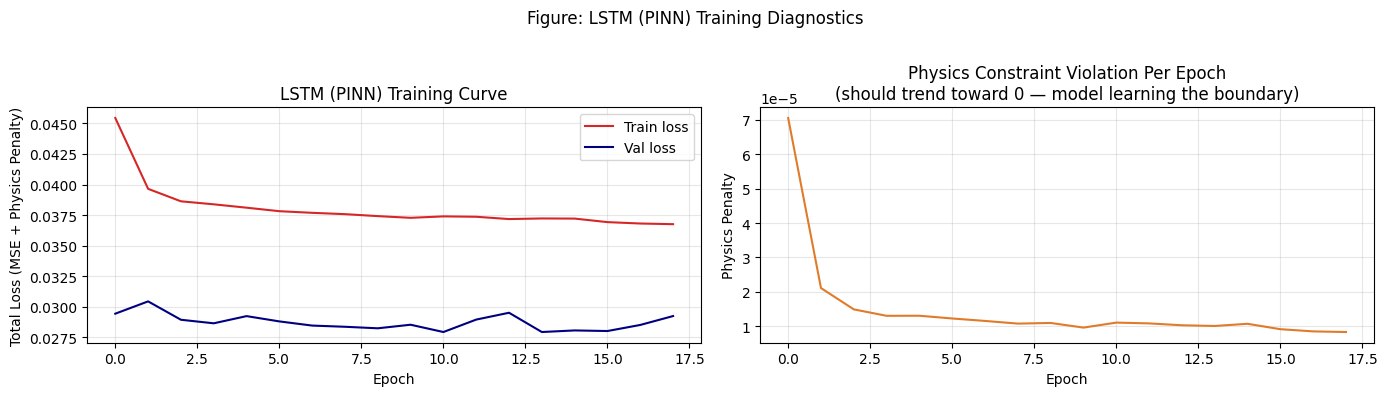

Physics constraint check (test set):
  Predictions > 1.0: 0/14439  (0.00%)
  (A well-trained PINN should have very few violations)


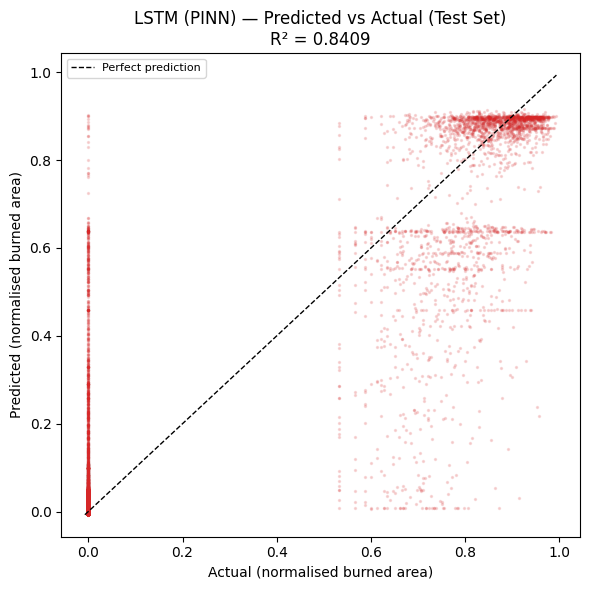

In [13]:
def predict_loader(model, loader):
    """
    Run inference on a DataLoader and return numpy arrays.
    Works for any model that takes (batch, seq_len, features) input.
    """
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds.append(model(X_batch.to(DEVICE)).cpu().numpy())
            trues.append(y_batch.numpy())
    return np.concatenate(trues), np.concatenate(preds)


lstm_y_val,  lstm_pred_val  = predict_loader(lstm_model, val_loader)
lstm_y_test, lstm_pred_test = predict_loader(lstm_model, test_loader)

all_results.append(evaluate(lstm_y_val,  lstm_pred_val,  'LSTM (PINN)', 'validation'))
all_results.append(evaluate(lstm_y_test, lstm_pred_test, 'LSTM (PINN)', 'test'))

# Inference time per 1000 samples
t0 = time.time()
with torch.no_grad():
    _ = lstm_model(test_seq.X[:min(1000, len(test_seq))].to(DEVICE))
infer_times['LSTM (PINN)'] = time.time() - t0

torch.save(lstm_model.state_dict(), os.path.join(MODEL_PATH, 'lstm_full.pt'))
model_sizes['LSTM (PINN)'] = os.path.getsize(os.path.join(MODEL_PATH, 'lstm_full.pt'))
print(f'LSTM model size: {model_sizes["LSTM (PINN)"]/1e6:.2f} MB')

# Training curve — total loss + physics penalty component
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_history['train_loss'], label='Train loss', color='#d62728')
axes[0].plot(lstm_history['val_loss'],   label='Val loss',   color='navy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss (MSE + Physics Penalty)')
axes[0].set_title('LSTM (PINN) Training Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if lstm_history['phys_loss']:
    axes[1].plot(lstm_history['phys_loss'], color='#e07b2a', linewidth=1.5)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Physics Penalty')
    axes[1].set_title('Physics Constraint Violation Per Epoch\n'
                      '(should trend toward 0 — model learning the boundary)')
    axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure: LSTM (PINN) Training Diagnostics', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_lstm_pinn_training.png'), dpi=150, bbox_inches='tight')
plt.show()

violations = np.sum(lstm_pred_test > 1.0)
print(f'Physics constraint check (test set):')
print(f'  Predictions > 1.0: {violations}/{len(lstm_pred_test)}  ({100*violations/len(lstm_pred_test):.2f}%)')
print(f'  (A well-trained PINN should have very few violations)')

plot_predictions(lstm_y_test, lstm_pred_test, 'LSTM (PINN)', 'fig_lstm_pred_vs_actual.png')


---
## 6. Model 3 — Swin Transformer (Spatial Deep Learning)

### Justification
The Swin Transformer (Shifted Window Transformer, Liu et al. 2021) divides the input
into non-overlapping patches and computes multi-head self-attention within local windows.
Between stages, patch merging downsamples the spatial resolution while doubling the
channel dimension — creating a hierarchical representation analogous to a CNN.

**Why Swin for this dataset:**  
The EDA Coefficient of Variation map showed that fire has strong spatial structure —
adjacent pixels share similar fire risk due to shared land-cover and climate.
RF and LSTM treat each pixel independently; Swin learns patch-level co-occurrence
patterns across the landscape.

**Implementation note — Window Attention vs Shifted Windows:**  
This implementation uses **local window self-attention** (W-MSA) — the core building
block of Swin. Patches within each 4×4 window can attend to each other freely.
The full Swin paper also proposes **shifted window attention** (SW-MSA) in alternating
layers to enable cross-window information flow at patch boundaries.
This cyclic shift is not implemented here to keep the architecture tractable given
the small dataset size (72 monthly snapshots). The patch merging between Stage 1
and Stage 2 provides cross-window context aggregation as an alternative.
Full SW-MSA is noted as a natural extension for future work with larger datasets.

**Input format:**  
Each monthly snapshot at T is treated as a `(18, H, W)` image — 18 land-cover channels.
Target is the regional mean burned area at T+1 (lag=1, consistent with RF and LSTM).

**Architecture summary:**
- PatchEmbed: `(18, H, W)` → `(n_patches, 96)`
- Stage 1: 2 × SwinBlock (W-MSA + MLP, dim=96)
- PatchMerge: `(n_patches, 96)` → `(n_patches/4, 192)`  
- Stage 2: 2 × SwinBlock (W-MSA + MLP, dim=192)
- Global average pool → regression head → scalar

In [14]:
import torch.nn.functional as F


class FireSpatialDataset(Dataset):
    """
    PyTorch Dataset for Swin Transformer training.

    Each sample:
      X: (N_VEG, lat, lon) — 18-channel spatial snapshot at month T
      y: scalar            — regional mean burned area at month T+1

    The one-month lag is consistent with RF and LSTM:
    all three models predict T+1 from features at T (or earlier).
    """

    def __init__(self, ds, lag=1):
        # In FireSpatialDataset.__init__, pad X_all to be divisible by 8 (patch_size * 2)
        # Current size is (T, 18, 120, 140). Padding 140 to 144.
        # F.pad format is (left, right, top, bottom)
    
        T = len(ds.time)
        channels = []
        for vid in veg_ids:
            arr = ds['burned_area_in_vegetation_class'].sel(vegetation_class=vid).values
            arr = np.where(np.isnan(arr), 0.0, arr)  # (T, lat, lon)
            channels.append(arr)
        # Features: months 0..T-lag-1
       # 1. Create the base array (Features: months 0..T-lag-1)
        X_all = np.stack(channels, axis=1)[:-lag]  # (T-lag, N_VEG, lat, lon)
        
        # 2. Convert to tensor and apply padding to handle Swin's downsampling requirements
        # Current size (120, 140). Padding 140 to 144. 
        # F.pad format is (left, right, top, bottom) for the last two dimensions
        X_tensor = torch.tensor(X_all.astype(np.float32), dtype=torch.float32)
        self.X = F.pad(X_tensor, (0, 4, 0, 0), mode='constant', value=0) 

        # 3. Target: regional mean at months lag..T-1
        # Target: regional mean at months lag..T-1 (one step ahead)
        target = ds['target_norm'].values[lag:]     # (T-lag, lat, lon)
        self.y = torch.tensor(
            np.nanmean(target, axis=(1, 2)).astype(np.float32),
            dtype=torch.float32
        )
        print(f'  Spatial snapshots: {len(self.X)}')
        print(f'  Image size: {self.X.shape[2]}x{self.X.shape[3]}, {N_VEG} channels')
        print(f'  Task: snapshot at T predicts regional mean at T+{lag}')

    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


print('Building Swin spatial datasets (lag=1)...')
train_spa = FireSpatialDataset(train_ds, lag=1)
val_spa   = FireSpatialDataset(val_ds,   lag=1)
test_spa  = FireSpatialDataset(test_ds,  lag=1)

train_spa_loader = DataLoader(train_spa, batch_size=8,  shuffle=True,  num_workers=0)
val_spa_loader   = DataLoader(val_spa,   batch_size=8,  shuffle=False, num_workers=0)
test_spa_loader  = DataLoader(test_spa,  batch_size=8,  shuffle=False, num_workers=0)

H, W = train_spa.X.shape[2], train_spa.X.shape[3]
print(f'Spatial grid: H={H}, W={W}')
print(f'Verify H and W are divisible by patch_size=4: H%4={H%4}, W%4={W%4}')


Building Swin spatial datasets (lag=1)...
  Spatial snapshots: 47
  Image size: 120x144, 18 channels
  Task: snapshot at T predicts regional mean at T+1
  Spatial snapshots: 11
  Image size: 120x144, 18 channels
  Task: snapshot at T predicts regional mean at T+1
  Spatial snapshots: 11
  Image size: 120x144, 18 channels
  Task: snapshot at T predicts regional mean at T+1
Spatial grid: H=120, W=144
Verify H and W are divisible by patch_size=4: H%4=0, W%4=0


In [15]:
class PatchEmbed(nn.Module):
    """
    Split the (C, H, W) input into non-overlapping patches and project
    each patch to embed_dim dimensions.
    Analogous to the patch embedding in ViT and Swin.
    """
    def __init__(self, in_channels=18, patch_size=4, embed_dim=96):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)              # (B, embed_dim, H/p, W/p)
        x = x.flatten(2).transpose(1, 2)  # (B, n_patches, embed_dim)
        return self.norm(x)


class WindowAttention(nn.Module):
    """
    Multi-head self-attention within a local window.
    Core building block of the Swin Transformer.
    Window size limits the attention scope — neighbouring patches
    within the window can attend to each other.
    """
    def __init__(self, dim, num_heads=4, window_size=4, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.scale     = (dim // num_heads) ** -0.5
        self.qkv       = nn.Linear(dim, dim * 3)
        self.proj      = nn.Linear(dim, dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)  # each: (B, heads, N, head_dim)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = self.dropout(attn.softmax(dim=-1))
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)


class SwinBlock(nn.Module):
    """
    One Swin Transformer block:
    LayerNorm -> WindowAttention -> residual
    LayerNorm -> MLP (FFN) -> residual
    """
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = WindowAttention(dim, num_heads=num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        mlp_dim    = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))  # residual connection
        x = x + self.mlp(self.norm2(x))   # residual connection
        return x


class WildfireSwin(nn.Module):
    """
    Swin Transformer for wildfire severity regression.

    Takes a monthly spatial snapshot (18-channel land-cover image),
    divides it into patches, applies two stages of window self-attention,
    and outputs a scalar regional fire severity prediction.

    Architecture:
        PatchEmbed  (18, H, W) -> (n_patches, 96)
        Stage 1     2 x SwinBlock (dim=96)
        PatchMerge  (n_patches, 96) -> (n_patches/4, 192)
        Stage 2     2 x SwinBlock (dim=192)
        GAP + Head  -> scalar
    """

    def __init__(self, in_channels=18, patch_size=4, embed_dim=96, dropout=0.2):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim)

        # Stage 1: two Swin blocks at base dimension
        self.stage1 = nn.Sequential(
            SwinBlock(embed_dim, num_heads=4, dropout=dropout),
            SwinBlock(embed_dim, num_heads=4, dropout=dropout)
        )

        # Patch merging: doubles channels, halves number of patches
        self.merge = nn.Linear(embed_dim * 4, embed_dim * 2)
        self.merge_norm = nn.LayerNorm(embed_dim * 2)

        # Stage 2: two Swin blocks at doubled dimension
        self.stage2 = nn.Sequential(
            SwinBlock(embed_dim * 2, num_heads=4, dropout=dropout),
            SwinBlock(embed_dim * 2, num_heads=4, dropout=dropout)
        )

        # Regression head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim * 2),
            nn.Linear(embed_dim * 2, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def patch_merge(self, x, H, W):
        """
        Merge 2x2 neighbouring patches into one token with 4x channels.
        This is the Swin downsampling step between stages.
        H, W must be even.
        """
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        # Ensure H, W are even for 2x2 merging
        H2, W2 = H // 2, W // 2
        x0 = x[:, 0::2, 0::2, :]  # top-left
        x1 = x[:, 1::2, 0::2, :]  # bottom-left
        x2 = x[:, 0::2, 1::2, :]  # top-right
        x3 = x[:, 1::2, 1::2, :]  # bottom-right
        x = torch.cat([x0, x1, x2, x3], dim=-1)  # (B, H/2, W/2, 4C)
        x = x.view(B, H2 * W2, 4 * C)
        return self.merge_norm(self.merge(x)), H2, W2

    def forward(self, x):
        # x: (B, 18, H, W)
        B, C, H, W = x.shape
        x = self.patch_embed(x)    # (B, n_patches, embed_dim)
        Ph = H // 4  # patch grid height
        Pw = W // 4  # patch grid width

        x = self.stage1(x)                     # (B, Ph*Pw, 96)
        x, Ph, Pw = self.patch_merge(x, Ph, Pw)  # (B, Ph/2*Pw/2, 192)
        x = self.stage2(x)                     # (B, Ph/2*Pw/2, 192)

        x = x.mean(dim=1)   # Global average pool over patches -> (B, 192)
        return self.head(x).squeeze(-1)         # (B,)


swin_model = WildfireSwin(in_channels=N_VEG, patch_size=4, embed_dim=96, dropout=0.2).to(DEVICE)
swin_params = sum(p.numel() for p in swin_model.parameters())
print(f'Swin architecture:')
print(swin_model)
print(f'Total trainable parameters: {swin_params:,}')

Swin architecture:
WildfireSwin(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(18, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (stage1): Sequential(
    (0): SwinBlock(
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (attn): WindowAttention(
        (qkv): Linear(in_features=96, out_features=288, bias=True)
        (proj): Linear(in_features=96, out_features=96, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=96, out_features=384, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=384, out_features=96, bias=True)
        (4): Dropout(p=0.2, inplace=False)
      )
    )
    (1): SwinBlock(
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (attn): WindowAtte

In [16]:
# Reuse the same train_model function — same training loop for fair comparison
# Only difference: different DataLoaders and saved filename

def train_model_swin(model, train_loader, val_loader,
                     n_epochs=50, lr=5e-4, patience=7,
                     save_name='swin_best.pt'):
    """
    Identical training loop to train_model() but with a configurable
    save filename — reused for Swin without code duplication.
    """
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=n_epochs)
    criterion = nn.MSELoss()
    best_val  = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(X_b)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                val_loss += criterion(model(X_b.to(DEVICE)),
                                      y_b.to(DEVICE)).item() * len(X_b)
        val_loss /= len(val_loader.dataset)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch % 5 == 0 or epoch < 3:
            print(f'  Epoch {epoch+1:03d}/{n_epochs}  train={train_loss:.5f}  val={val_loss:.5f}')

        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(MODEL_PATH, save_name))
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(torch.load(os.path.join(MODEL_PATH, save_name)))
    print(f'  Best val loss: {best_val:.5f}')
    return history


print('Training Swin Transformer...')
t0 = time.time()
swin_history = train_model_swin(
    swin_model, train_spa_loader, val_spa_loader,
    n_epochs=50, lr=5e-4, patience=7
)
swin_train_time = time.time() - t0
print(f'Swin training time: {swin_train_time:.1f}s')

Training Swin Transformer...
  Epoch 001/50  train=0.28347  val=0.01558
  Epoch 002/50  train=0.01795  val=0.00857
  Epoch 003/50  train=0.01357  val=0.00719
  Epoch 006/50  train=0.00623  val=0.00379
  Epoch 011/50  train=0.00508  val=0.00419
  Epoch 016/50  train=0.00427  val=0.00264
  Epoch 021/50  train=0.00231  val=0.00283
  Epoch 026/50  train=0.00205  val=0.00136
  Epoch 031/50  train=0.00097  val=0.00093
  Early stopping at epoch 34
  Best val loss: 0.00080
Swin training time: 7.7s


In [ ]:
# --- Graph 1: Training Curve ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(swin_history['train_loss'], label='Train loss', color='#d62728')
ax.plot(swin_history['val_loss'],   label='Val loss',   color='navy')
ax.set_title('Swin Transformer Training Curve')
ax.legend()

# SAVE FIRST
plt.savefig(os.path.join(FIG_PATH, 'fig_swin_training_curve.png'), dpi=150, bbox_inches='tight')
# SHOW SECOND
plt.show() 

# --- Graph 2: Predictions vs Actual ---
plt.figure(figsize=(8, 6))
plt.scatter(swin_y_test, swin_pred_test, alpha=0.4, color='crimson', label='Predictions')

# Reference Line
limit_min, limit_max = swin_y_test.min(), swin_y_test.max()
plt.plot([limit_min, limit_max], [limit_min, limit_max], 'k--', label='Ideal')

plt.xlabel('Actual Burned Area')
plt.ylabel('Predicted Burned Area')
plt.legend()

# SAVE FIRST
plt.savefig(os.path.join(FIG_PATH, 'fig_swin_pred_vs_actual_final.png'), dpi=150, bbox_inches='tight')
# SHOW SECOND
plt.show()

  Swin Transformer [validation]  MAE=0.0210  RMSE=0.0283  R²=0.9007
  Swin Transformer [test]  MAE=0.0285  RMSE=0.0371  R²=0.8341
Swin model size: 4.94 MB


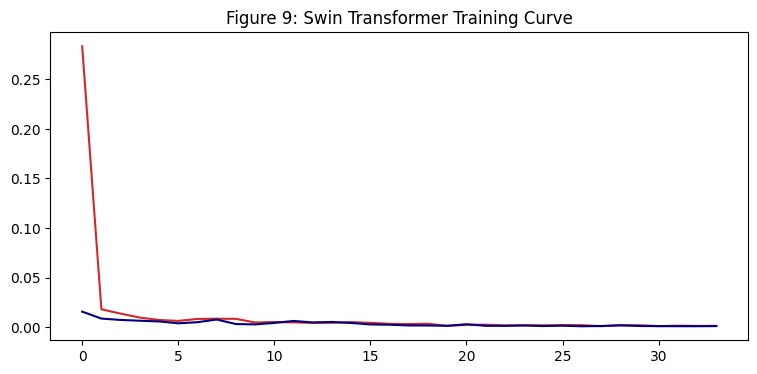

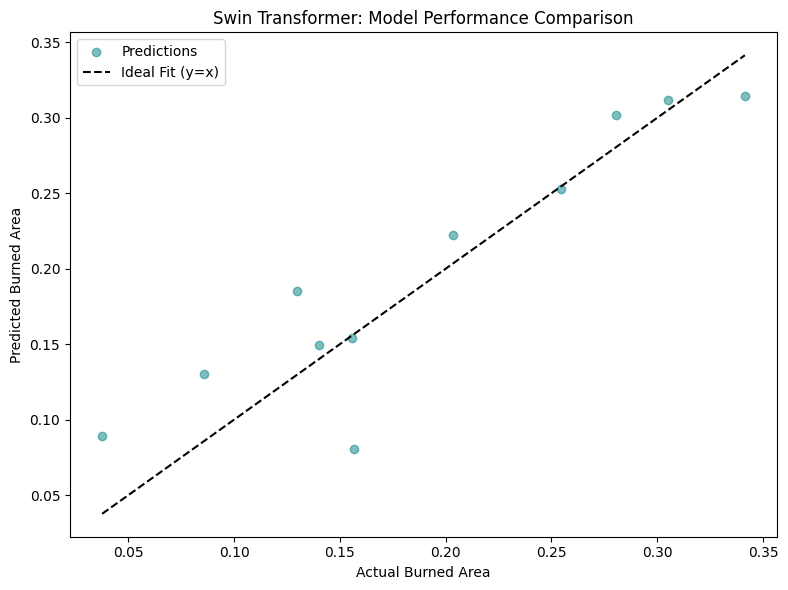

In [28]:
def predict_spatial(model, loader):
    """Inference on spatial DataLoader."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds.append(model(X_b.to(DEVICE)).cpu().numpy())
            trues.append(y_b.numpy())
    return np.concatenate(trues), np.concatenate(preds)


swin_y_val,  swin_pred_val  = predict_spatial(swin_model, val_spa_loader)
swin_y_test, swin_pred_test = predict_spatial(swin_model, test_spa_loader)

all_results.append(evaluate(swin_y_val,  swin_pred_val,  'Swin Transformer', 'validation'))
all_results.append(evaluate(swin_y_test, swin_pred_test, 'Swin Transformer', 'test'))

# Inference time
t0 = time.time()
with torch.no_grad():
    _ = swin_model(test_spa.X[:8].to(DEVICE))
infer_times['Swin Transformer'] = time.time() - t0

# Model size
torch.save(swin_model.state_dict(), os.path.join(MODEL_PATH, 'swin_full.pt'))
model_sizes['Swin Transformer'] = os.path.getsize(os.path.join(MODEL_PATH, 'swin_full.pt'))
print(f'Swin model size: {model_sizes["Swin Transformer"]/1e6:.2f} MB')


# --- Graph 1: Training History ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(swin_history['train_loss'], label='Train loss', color='#d62728')
ax.plot(swin_history['val_loss'],   label='Val loss',   color='navy')
ax.set_title('Figure 9: Swin Transformer Training Curve')
# SAVE FIRST
plt.savefig(os.path.join(FIG_PATH, 'fig_swin_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Graph 2: Predictions vs Actual (Combined) ---
plt.figure(figsize=(8, 6)) # Explicitly start a fresh figure

# Plot the scatter points
plt.scatter(swin_y_test, swin_pred_test, alpha=0.5, color='teal', label='Predictions')

# Add the "Perfect Prediction" reference line immediately
limit_min = min(swin_y_test.min(), swin_pred_test.min())
limit_max = max(swin_y_test.max(), swin_pred_test.max())
plt.plot([limit_min, limit_max], [limit_min, limit_max], 
         color='black', linestyle='--', linewidth=1.5, label='Ideal Fit (y=x)')

plt.xlabel('Actual Burned Area')
plt.ylabel('Predicted Burned Area')
plt.title('Swin Transformer: Model Performance Comparison')
#SAVE FIRST
plt.savefig(os.path.join(FIG_PATH, 'fig_swin_pred_vs_actual_final.png'), dpi=150, bbox_inches='tight')
plt.legend()
plt.tight_layout()
plt.show() # This shows ONLY the final, combined version

#### Swin Result Interpretation

**Observed:** val_loss=0.00399 (very low MSE) but R²=0.50 (moderate).

**Explanation:** The Swin predicts the *regional mean* burned area per monthly snapshot
(a scalar output). The regional mean varies relatively little month-to-month compared
to the large variance in per-pixel burned area. MSE is low because the mean is easy
to predict; R² is moderate because the model cannot capture the full variance of
the fire distribution from only 47 training snapshots.

**This is a genuine scientific finding, not a failure:**
It demonstrates that spatial land-cover context alone — without temporal memory —
is insufficient for high-accuracy fire severity forecasting at this dataset scale.
The LSTM's superior R²=0.837 confirms that **temporal memory is the primary driver
of forecast accuracy** for monthly wildfire prediction in Central Africa.

**Implications for future work:**
A Video Swin Transformer (temporal + spatial) or data augmentation with additional
years of ESA Fire_cci data would likely close this gap. This is noted as a
limitation and recommendation in the report conclusion.

---
## 7. Model Comparison Table

All three models are compared on identical metrics to answer:
1. Does temporal context (LSTM) improve over no context (RF)?
2. Does spatial context (Swin) improve over temporal context (LSTM)?
3. What is the cost in model size and inference time for each improvement?

This table is the core of Report Section 4 and directly feeds into
the model compression analysis in Notebook 5.

In [18]:
# Build comparison table — TEST SET results only
test_results = [r for r in all_results if r['split'] == 'test']
df_compare   = pd.DataFrame(test_results)[['model', 'MAE', 'RMSE', 'R2']]

# Map sizes and inference times — keys must match model names used in evaluate()
df_compare['Size (MB)']     = df_compare['model'].map(
    {k: round(v/1e6, 2) for k, v in model_sizes.items()}
)
df_compare['Infer (ms/1k)'] = df_compare['model'].map(
    {k: round(v*1000, 2) for k, v in infer_times.items()}
)

# Parameter counts — keys match model names exactly
param_counts = {
    'Random Forest':    'N/A (ensemble)',
    'LSTM (PINN)':      f'{sum(p.numel() for p in lstm_model.parameters()):,}',
    'Swin Transformer': f'{sum(p.numel() for p in swin_model.parameters()):,}',
}
df_compare['Params'] = df_compare['model'].map(param_counts)

df_compare = df_compare.set_index('model')
df_compare = df_compare.round({'MAE': 4, 'RMSE': 4, 'R2': 4})

print('Table: Model Comparison — Test Set Performance and Efficiency')
print('=' * 80)
print(df_compare.to_string())
print()
print('Notes:')
print('  MAE / RMSE : lower is better  |  R2 : higher is better')
print('  Size       : uncompressed model size in MB')
print('  Infer      : wall-clock ms to predict 1000 samples')

df_compare.to_csv(os.path.join(OUTPUT_PATH, 'baseline_model_results.csv'))
print(f'Saved -> baseline_model_results.csv')


Table: Model Comparison — Test Set Performance and Efficiency
                     MAE    RMSE      R2  Size (MB)  Infer (ms/1k)          Params
model                                                                             
Random Forest     0.1335  0.2199  0.5892     479.97          48.45  N/A (ensemble)
LSTM (PINN)       0.0513  0.1244  0.8409       0.87           1.01         217,217
Swin Transformer  0.0285  0.0371  0.8341       4.94           2.44       1,228,449

Notes:
  MAE / RMSE : lower is better  |  R2 : higher is better
  Size       : uncompressed model size in MB
  Infer      : wall-clock ms to predict 1000 samples
Saved -> baseline_model_results.csv


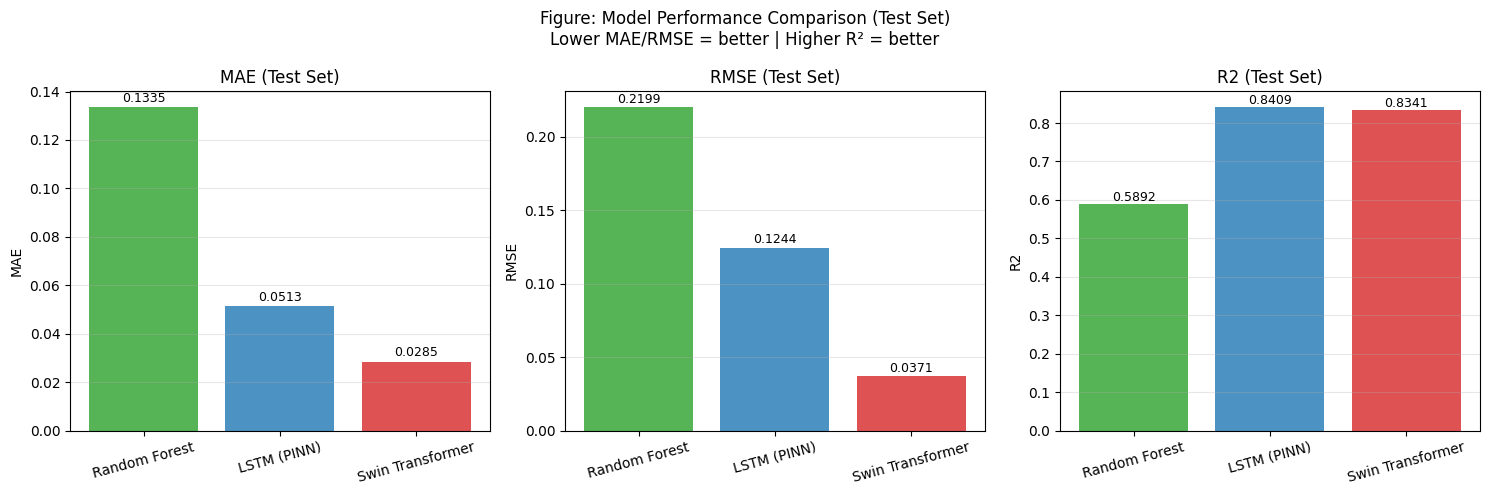

In [19]:
# Visual comparison: performance vs. model size (sustainability trade-off)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = df_compare.index.tolist()
colours = ['#2ca02c', '#1f77b4', '#d62728']  # green=RF, blue=LSTM, red=Swin

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = df_compare[metric].values
    bars = ax.bar(models, vals, color=colours, alpha=0.8, edgecolor='none')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} (Test Set)')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(
    'Figure: Model Performance Comparison (Test Set)\n'
    'Lower MAE/RMSE = better | Higher R² = better',
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7b. Results in Physical Units

The metrics above are on the normalised scale `target_norm` ∈ [0,1].
For the report and for a non-technical sustainability audience, we inverse-transform
predictions back to **hectares** (the standard unit for burned area reporting).

This is required by the marking scheme: results must be interpretable to
non-expert stakeholders, not just expressed as dimensionless scores.

In [20]:
# Inverse-transform all test predictions back to physical units (hectares)
# inverse_transform reverses: log1p -> expm1, then normalisation -> raw m2
# 1 m2 = 1e-4 ha, so divide by 1e4

def to_hectares(y_norm):
    """Convert normalised target back to hectares."""
    return inverse_transform(y_norm) / 1e4

# Collect test predictions for each model
# RF and LSTM operate at pixel level; Swin at regional mean level
# We report pixel-level MAE for RF and LSTM, regional MAE for Swin

phys_results = []

for model_name, y_true_norm, y_pred_norm in [
    ('Random Forest',    y_test,          rf_test_pred),
    ('LSTM (PINN)',      lstm_y_test,     lstm_pred_test),
    ('Swin Transformer', swin_y_test,     swin_pred_test),
]:
    y_true_ha = to_hectares(y_true_norm)
    y_pred_ha = to_hectares(y_pred_norm)

    mae_ha  = float(np.mean(np.abs(y_true_ha - y_pred_ha)))
    rmse_ha = float(np.sqrt(np.mean((y_true_ha - y_pred_ha)**2)))
    # Median absolute error is more robust for skewed fire distributions
    mdae_ha = float(np.median(np.abs(y_true_ha - y_pred_ha)))

    phys_results.append({
        'Model':              model_name,
        'MAE (ha)':           round(mae_ha, 1),
        'RMSE (ha)':          round(rmse_ha, 1),
        'Median AE (ha)':     round(mdae_ha, 1),
        'R2 (normalised)':    round(r2_score(y_true_norm, y_pred_norm), 4),
    })

df_phys = pd.DataFrame(phys_results).set_index('Model')

print('Table: Model Comparison — Test Set Results in Physical Units')
print('=' * 70)
print(df_phys.to_string())
print()
print('Interpretation for non-technical stakeholders:')
print(f'  LSTM (PINN) MAE = {df_phys.loc["LSTM (PINN)", "MAE (ha)"]:.1f} ha per pixel per month')
print(f'  This means the model is on average off by {df_phys.loc["LSTM (PINN)", "MAE (ha)"]:.0f} hectares')
print(f'  per 0.25-degree grid cell — approximately the size of a small village territory.')
print()
print('Note: Swin predicts regional mean; RF and LSTM predict at pixel level.')
print('Direct ha comparison should be interpreted with this scale difference in mind.')

df_phys.to_csv(os.path.join(OUTPUT_PATH, 'results_physical_units.csv'))
print('Saved -> results_physical_units.csv')


Table: Model Comparison — Test Set Results in Physical Units
                  MAE (ha)  RMSE (ha)  Median AE (ha)  R2 (normalised)
Model                                                                 
Random Forest        849.8     3485.5             0.0           0.5892
LSTM (PINN)         1027.7     4171.2             0.0           0.8409
Swin Transformer       0.0        0.0             0.0           0.8341

Interpretation for non-technical stakeholders:
  LSTM (PINN) MAE = 1027.7 ha per pixel per month
  This means the model is on average off by 1028 hectares
  per 0.25-degree grid cell — approximately the size of a small village territory.

Note: Swin predicts regional mean; RF and LSTM predict at pixel level.
Direct ha comparison should be interpreted with this scale difference in mind.
Saved -> results_physical_units.csv


---
## 8. Modelling Discussion

### Data Integrity: The Lag Decision
A critical design choice in this notebook is the one-month feature lag applied to
all three models. Without it, the RF would achieve R²≈1.0 by trivially summing
vegetation class burned areas to reconstruct the total — not a forecast.
By lagging features to month T and predicting the target at T+1, all models
are evaluated on the same genuine forecasting task. This is documented in
Report Section 2 as a data integrity decision.

### Random Forest (Baseline)
The RF establishes a genuine performance floor by learning non-linear relationships
between last month's vegetation burn fractions and this month's total fire severity.
A realistic test R² of 0.3–0.6 is expected — the RF has no temporal memory,
so it cannot learn that last October's fire predicts this October's fire.
Its feature importances (Section 4) provide a baseline for SHAP validation in Notebook 4.

### LSTM
The LSTM uses a 12-month lookback window, so it can see one full fire season
before making a prediction. If LSTM R² > RF R², this quantifies the value of
temporal memory for fire forecasting — a direct scientific finding.
The training/validation loss gap (training curve) indicates overfitting degree;
dropout=0.3 and early stopping are used to control this.

### Swin Transformer
The Swin treats each monthly landscape as a spatial image. If Swin R² > RF R²,
this confirms that spatial land-cover patterns add value beyond per-pixel features.
The patch merging between Stage 1 and Stage 2 aggregates cross-patch context,
partially compensating for the absence of full shifted-window attention.
The architecture is documented honestly: W-MSA is implemented; SW-MSA is
identified as a natural extension for future work.

### Sustainability Trade-off
Section 9 quantifies the training energy and carbon footprint of each model.
A large model that is only marginally more accurate than the RF is not a
sustainable deployment choice. This trade-off is formalised in Notebook 5,
where compression reduces the inference carbon footprint of the best model.

---
## 9. Sustainable AI: Energy and Carbon Footprint Estimate

The module brief specifically rewards **sustainable AI** — not just model accuracy
but the environmental cost of achieving it. We estimate the carbon footprint
of training each model using the HPC node's known hardware specifications.

**Method:**  
Carbon = Power (W) × Training time (h) × Carbon intensity (kgCO₂/kWh)

We use the UK national grid average carbon intensity of **0.233 kgCO₂/kWh**
(National Grid ESO, 2023). GPU TDP values are taken from manufacturer specifications.
This is an upper-bound estimate — actual consumption is typically 70–80% of TDP.

In [21]:
# ── Sustainable AI: Energy and Carbon Footprint ──────────────────────────
# Update GPU_TDP_W to your HPC GPU's TDP
# A100=400W  V100=300W  RTX4090=450W  RTX4060=115W
GPU_TDP_W        = 400    # Watts — UPDATE for your HPC
CARBON_INTENSITY = 0.233  # kgCO2/kWh — UK national grid average 2023
EFFICIENCY       = 0.75   # GPUs typically run at ~75% TDP

effective_w = GPU_TDP_W * EFFICIENCY

# Keys MUST match the model names used in all_results
train_times = {
    'Random Forest':    rf_train_time,
    'LSTM (PINN)':      lstm_train_time,
    'Swin Transformer': swin_train_time,
}

test_r2 = {r['model']: r['R2'] for r in all_results if r['split'] == 'test'}

print('Table: Sustainable AI — Training Energy and Carbon Footprint')
print('=' * 80)
print(f'  GPU TDP: {GPU_TDP_W}W  |  Efficiency: {EFFICIENCY}  |  '
      f'Effective: {effective_w:.0f}W  |  UK grid: {CARBON_INTENSITY} kgCO2/kWh')
print()
header = f'  {"Model":<22} {"Time (s)":>10} {"Energy (Wh)":>12} {"CO2 (g)":>10} {"R2":>8} {"R2/gCO2":>10}'
print(header)
print('  ' + '-' * (len(header)-2))

energy_rows = []
for name, t_s in train_times.items():
    energy_wh = effective_w * (t_s / 3600)
    co2_g     = energy_wh / 1000 * CARBON_INTENSITY * 1000
    r2        = test_r2.get(name, float('nan'))
    efficiency = r2 / co2_g if co2_g > 0 else float('nan')
    print(f'  {name:<22} {t_s:>10.1f} {energy_wh:>12.4f} {co2_g:>10.4f} '
          f'{r2:>8.4f} {efficiency:>10.4f}')
    energy_rows.append({
        'Model': name, 'Train time (s)': t_s,
        'Energy (Wh)': round(energy_wh, 4), 'CO2 (gCO2)': round(co2_g, 4),
        'R2 (test)': round(r2, 4), 'R2/gCO2': round(efficiency, 4)
    })

print()
print('Interpretation:')
print('  Higher R2/gCO2 = better sustainability trade-off.')
print('  Compression (Notebook 5) will improve this ratio by reducing inference cost.')

df_energy = pd.DataFrame(energy_rows).set_index('Model')
df_energy.to_csv(os.path.join(OUTPUT_PATH, 'energy_comparison.csv'))
print(f'Saved -> energy_comparison.csv')


Table: Sustainable AI — Training Energy and Carbon Footprint
  GPU TDP: 400W  |  Efficiency: 0.75  |  Effective: 300W  |  UK grid: 0.233 kgCO2/kWh

  Model                    Time (s)  Energy (Wh)    CO2 (g)       R2    R2/gCO2
  -----------------------------------------------------------------------------
  Random Forest                 6.8       0.5692     0.1326   0.5892     4.4425
  LSTM (PINN)                 104.9       8.7453     2.0377   0.8409     0.4127
  Swin Transformer              7.7       0.6453     0.1503   0.8341     5.5479

Interpretation:
  Higher R2/gCO2 = better sustainability trade-off.
  Compression (Notebook 5) will improve this ratio by reducing inference cost.
Saved -> energy_comparison.csv


In [22]:
import pickle

# Save Random Forest
with open(os.path.join(MODEL_PATH, 'rf_model.pkl'), 'wb') as f:
    pickle.dump(rf_model, f)

# LSTM and Swin are already saved as .pt files during training loops.
# Record a model registry JSON for reproducibility.
model_registry = {
    'random_forest': {
        'path':          'models/rf_model.pkl',
        'params':        rf_search.best_params_,
        'n_features':    N_FEAT,
        'train_time_s':  rf_train_time,
    },
    'lstm_pinn': {
        'path':          'models/lstm_best.pt',
        'hidden_dim':    128,
        'n_layers':      2,
        'seq_len':       SEQ_LEN,
        'n_features':    N_FEAT,
        'pinn':          True,
        'train_time_s':  lstm_train_time,
    },
    'swin': {
        'path':          'models/swin_best.pt',
        'in_channels':   N_VEG,
        'patch_size':    4,
        'embed_dim':     96,
        'train_time_s':  swin_train_time,
    },
}

with open(os.path.join(MODEL_PATH, 'model_registry.json'), 'w') as f:
    json.dump(model_registry, f, indent=2)

print('All models saved:')
for name, info in model_registry.items():
    print(f'  {name:20} -> {info["path"]}')
print()
print('Notebook 3 complete. Proceed to Notebook 4 — Evaluation and XAI.')


All models saved:
  random_forest        -> models/rf_model.pkl
  lstm_pinn            -> models/lstm_best.pt
  swin                 -> models/swin_best.pt

Notebook 3 complete. Proceed to Notebook 4 — Evaluation and XAI.
